In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
os.chdir('..')  # go up from source_code/ to project root

## Apartments

In [6]:
apartments = pd.read_csv('data/raw/apartments.csv')

apartments['full_cost'] = apartments['price'] + apartments['charges']
apartments['disposition_clean'] = (
    apartments['disposition']
    .str.replace('DISP_', '', regex=False)
    .str.replace('_', '+')
)
apartments['district'] = apartments['district'].str.replace('Praha-', '', regex=False)
apartments['price_per_m2'] = apartments['full_cost'] / apartments['surface']

# remove undefined dispositions
apartments['disposition_clean'] = apartments['disposition_clean'].replace(['UNDEFINED', 'OSTATNI'], np.nan)

# drop duplicates
apartments = apartments.drop_duplicates()

# remove extreme sizes
apartments = apartments[(apartments['surface'] > 10) & (apartments['surface'] <= 250)]

# cap at 95th percentile — removes luxury outliers beyond student affordability
apartments = apartments[apartments['full_cost'] < apartments['full_cost'].quantile(0.95)]

print(apartments.shape)
apartments.head()

(1272, 9)


,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182
1,40621,7168,40,UNDEFINED,"Starokošířská, Praha - Košíře",Košíře,47789,NaN,1194.725000
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686


In [7]:
center = [
    'Staré Město', 'Nové Město', 'Malá Strana'
]

inner_city = [
    'Vinohrady', 'Žižkov', 'Karlín', 'Smíchov',
    'Holešovice', 'Vršovice', 'Nusle', 'Dejvice',
    'Bubeneč', 'Podolí', 'Libeň', 'Vysočany',
    'Košíře', 'Břevnov', 'Střešovice', 'Vokovice',
    'Radlice', 'Jinonice', 'Hlubočepy', 'Braník',
    'Michle', 'Strašnice', 'Kobylisy', 'Prosek',
]

outer_city = [
    'Stodůlky', 'Chodov', 'Letňany', 'Krč',
    'Modřany', 'Záběhlice', 'Kyje', 'Kamýk',
    'Bohnice', 'Hostivař', 'Černý Most', 'Řepy',
    'Háje', 'Horní Měcholupy', 'Malešice', 'Troja',
    'Liboc', 'Lhotka', 'Štěrboholy', 'Horní Počernice',
    'Čimice', 'Libuš', 'Kunratice', 'Dolní Chabry',
    'Ďáblice', 'Hostavice', 'Dolní Počernice', 'Komořany',
    'Běchovice', 'Dubeč', 'Řeporyje',
]

def classify_zone(district):
    if district in center:       return 'center'
    elif district in inner_city: return 'inner_city'
    else:                        return 'outer_or_suburbs'

apartments['zone'] = apartments['district'].apply(classify_zone)

district_stats = apartments.groupby(['zone', 'disposition_clean']).agg(
    avg_rent=('full_cost', 'mean'),
    avg_m2_price=('price_per_m2', 'mean'),
    count=('full_cost', 'size')
).reset_index()

district_stats

,zone,disposition_clean,avg_rent,avg_m2_price,count
0,center,1+1,22566.666667,687.672533,3
1,center,1+KK,25472.857143,976.291126,7
2,center,2+1,35900.000000,498.213640,10
3,center,2+KK,32351.250000,718.018330,8
4,center,3+1,35800.000000,421.176471,1
5,center,3+KK,36000.000000,500.000000,3
6,inner_city,1+1,21398.333333,545.719975,36
7,inner_city,1+KK,21562.980892,706.096441,157
8,inner_city,2+1,27749.073171,469.820999,82
9,inner_city,2+KK,27787.143460,547.881861,237


In [8]:
keep = ['GARSONIERA', '1+KK', '1+1', '2+KK', '2+1', '3+KK', '3+1', '4+KK', '4+1']

apt_stats = (
    apartments[apartments['disposition_clean'].isin(keep)]
    .groupby(['zone', 'disposition_clean'])
    .agg(avg_rent=('full_cost', 'mean'), n=('full_cost', 'count'))
    .reset_index()
)

apt_stats

,zone,disposition_clean,avg_rent,n
0,center,1+1,22566.666667,3
1,center,1+KK,25472.857143,7
2,center,2+1,35900.000000,10
3,center,2+KK,32351.250000,8
4,center,3+1,35800.000000,1
5,center,3+KK,36000.000000,3
6,inner_city,1+1,21398.333333,36
7,inner_city,1+KK,21562.980892,157
8,inner_city,2+1,27749.073171,82
9,inner_city,2+KK,27787.143460,237


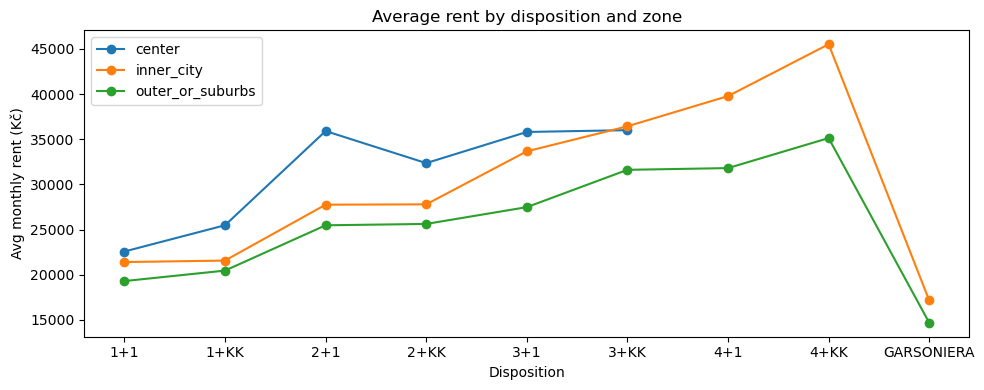

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for zone, grp in apt_stats.groupby('zone'):
    ax.plot(grp['disposition_clean'], grp['avg_rent'], marker='o', label=zone)
ax.set_xlabel('Disposition')
ax.set_ylabel('Avg monthly rent (Kč)')
ax.set_title('Average rent by disposition and zone')
ax.legend()
plt.tight_layout()
plt.show()

## Groceries

In [10]:
# weekly target quantities per item
# unit matches the target_unit in ITEMS (g, ml, piece)
WEEKLY_QTY = {
    # standard + shared
    'ovesne_vlocky':    500,    # g
    'mleko':            2000,   # ml  (2L)
    'banany':           1000,   # g   (~6 pieces)
    'chleb':            500,    # g   (~1 loaf)
    'maslo':            250,    # g
    'vejce':            10,     # pieces
    'spagety':          500,    # g
    'pesto':            190,    # g   (1 jar)
    'ryze':             500,    # g
    'mrazena_zelenina': 400,    # g
    'kureci_prsa':      500,    # g
    'tofu':             400,    # g
    'cibule':           500,    # g
    'cesnek':           80,     # g   (~1 head)
    'syr_eidam':        200,    # g
    'tunak':            370,    # g   (2x185g tins)
    'jogurt':           300,    # g   (2x150g)
    'kava':             250,    # g   (lasts longer but priced per pack)
    # vegan-only
    'ovesny_napoj':     1000,   # ml  (1L)
    'sojovy_napoj':     1000,   # ml  (1L)
    'repkovy_olej':     200,    # ml  (weekly portion of 1L bottle)
    'cervena_cocka':    500,    # g
    'rajcatova_omacka': 350,    # g   (1 jar)
    'paprika':          300,    # g   (~1-2 pieces)
}

BASKET_STANDARD = {
    'ovesne_vlocky', 'mleko', 'banany', 'chleb', 'maslo', 'vejce',
    'spagety', 'pesto', 'ryze', 'mrazena_zelenina', 'kureci_prsa',
    'tofu', 'cibule', 'cesnek', 'syr_eidam', 'tunak', 'jogurt', 'kava',
}

BASKET_VEGAN = {
    'ovesne_vlocky', 'banany', 'chleb', 'spagety', 'ryze',
    'mrazena_zelenina', 'tofu', 'cibule', 'cesnek', 'kava',
    'ovesny_napoj', 'sojovy_napoj', 'repkovy_olej',
    'cervena_cocka', 'rajcatova_omacka', 'paprika',
}

In [15]:
def parse_qty(text):
    """Parse quantity and unit from packaging string. Returns (qty, unit) or (None, None)."""
    if not text or pd.isna(text):
        return None, None
    t = str(text).lower().strip()
    if m := re.search(r'(\d+)\s*ks', t):                return int(m.group(1)), 'piece'
    if m := re.search(r'(\d+[,.]?\d*)\s*kg', t):        return float(m.group(1).replace(',', '.')) * 1000, 'g'
    if m := re.search(r'(\d+[,.]?\d*)\s*g(?!\w)', t):  return float(m.group(1).replace(',', '.')), 'g'
    if m := re.search(r'(\d+[,.]?\d*)\s*l(?!\w)', t):  return float(m.group(1).replace(',', '.')) * 1000, 'ml'
    if m := re.search(r'(\d+)\s*ml', t):                return int(m.group(1)), 'ml'
    return None, None


def weekly_cost(row):
    """Convert scraped price to weekly cost based on target quantity."""
    item = row['item']
    price = row['price_czk']
    if pd.isna(price):
        return np.nan
    target_qty = WEEKLY_QTY.get(item)
    if target_qty is None:
        return np.nan
    pack_qty, pack_unit = parse_qty(row.get('packaging', ''))
    # if we can parse the pack size, scale price to target quantity
    if pack_qty and pack_qty > 0:
        return price / pack_qty * target_qty
    # fallback: use price as-is (assume pack ≈ weekly qty)
    return price


def load_store(name):
    path = f'data/raw/rohlik_prices.csv' if name == 'rohlik' else f'data/raw/{name}_prices.csv'
    df = pd.read_csv(path)
    df['weekly_cost'] = df.apply(weekly_cost, axis=1)
    return df[['item', 'title', 'price_czk', 'packaging', 'weekly_cost']]

rohlik = load_store('rohlik')
kosik  = load_store('kosik')
billa  = load_store('billa')
lidl   = load_store('lidl')

# fix billa banana
billa.loc[billa['item'] == 'banany', 'weekly_cost'] = np.nan

rohlik.head()

,item,title,price_czk,packaging,weekly_cost
0,ovesne_vlocky,Yutto Celozrnné ovesné vločky extra jemné,11.90,500 g,11.900000
1,mleko,"Miil Trvanlivé polotučné mléko 1,5%",14.90,1 l,29.800000
2,banany,Banán 1 ks,6.95,cca 190 g,36.578947
3,chleb,Merhautovo pekařství Chléb žitný,35.90,400 g,44.875000
4,maslo,Miil Máslo 82%,44.90,250 g,44.900000


In [16]:
# merge all stores into one table
prices = (
    rohlik[['item', 'title', 'weekly_cost']].rename(columns={'title': 'title_rohlik', 'weekly_cost': 'rohlik'})
    .merge(kosik[['item', 'weekly_cost']].rename(columns={'weekly_cost': 'kosik'}), on='item', how='outer')
    .merge(billa[['item', 'weekly_cost']].rename(columns={'weekly_cost': 'billa'}), on='item', how='outer')
    .merge(lidl[['item', 'weekly_cost']].rename(columns={'weekly_cost': 'lidl'}),   on='item', how='outer')
)

prices['online_avg']   = prices[['rohlik', 'kosik']].mean(axis=1)
prices['physical_avg'] = prices[['billa', 'lidl']].mean(axis=1)

prices

,item,title_rohlik,rohlik,kosik,billa,lidl,online_avg,physical_avg
0,banany,Banán 1 ks,36.578947,39.900000,NaN,NaN,38.239474,NaN
1,cervena_cocka,Kitchin Červená čočka,33.900000,34.900000,29.900000,NaN,34.400000,29.900000
2,cesnek,"Česnek ""ošklivák"" český, síť",15.977143,5.192000,19.960000,39.900000,10.584571,29.930000
3,chleb,Merhautovo pekařství Chléb žitný,44.875000,17.708333,34.647059,29.506173,31.291667,32.076616
4,cibule,"Cibule žlutá, síť",9.950000,9.950000,10.450000,NaN,9.950000,10.450000
5,jogurt,Hollandia Nízkotučný jogurt bílý,14.131579,14.925000,13.740000,17.900000,14.528289,15.820000
6,kava,Ubomi Intense RFA mletá káva,84.900000,119.900000,79.900000,NaN,102.400000,79.900000
7,kureci_prsa,Kuřecí prsní řízky od českého výrobce XXL balení,109.950000,94.900000,129.950000,59.900000,102.425000,94.925000
8,maslo,Miil Máslo 82%,44.900000,43.625000,39.900000,19.388889,44.262500,29.644444
9,mleko,"Miil Trvanlivé polotučné mléko 1,5%",29.800000,19.800000,25.800000,25.800000,24.800000,25.800000


In [21]:
def basket_cost(prices_df, basket_items):
    """Weekly and monthly basket cost from a prices dataframe."""
    sub = prices_df[prices_df['item'].isin(basket_items)].copy()
    weekly_online   = sub['online_avg'].sum() + 60    # 60 Kč delivery fee per week
    weekly_physical = sub['physical_avg'].sum()
    return pd.Series({
        'weekly_online':    round(weekly_online, 1),
        'weekly_physical':  round(weekly_physical, 1),
        'monthly_online':   round(weekly_online * 4.33, 1),
        'monthly_physical': round(weekly_physical * 4.33, 1),
    })

standard_costs = basket_cost(prices, BASKET_STANDARD)
vegan_costs    = basket_cost(prices, BASKET_VEGAN)

summary = pd.DataFrame({'standard': standard_costs, 'vegan': vegan_costs})
print(summary)

                  standard   vegan
weekly_online        819.8   549.6
weekly_physical      702.0   462.7
monthly_online      3549.6  2380.0
monthly_physical    3039.6  2003.5


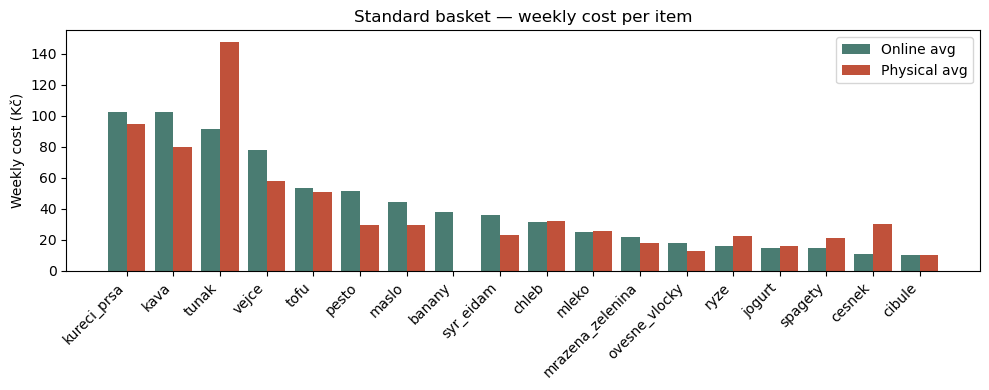

In [22]:
# per-item breakdown for standard basket
standard_breakdown = prices[prices['item'].isin(BASKET_STANDARD)][['item', 'rohlik', 'kosik', 'billa', 'lidl', 'online_avg', 'physical_avg']].copy()
standard_breakdown = standard_breakdown.sort_values('online_avg', ascending=False)

# quick bar chart — most expensive items
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(standard_breakdown))
ax.bar([i - 0.2 for i in x], standard_breakdown['online_avg'],   width=0.4, label='Online avg',   color='#4A7C72')
ax.bar([i + 0.2 for i in x], standard_breakdown['physical_avg'], width=0.4, label='Physical avg', color='#C0513A')
ax.set_xticks(list(x))
ax.set_xticklabels(standard_breakdown['item'], rotation=45, ha='right')
ax.set_ylabel('Weekly cost (Kč)')
ax.set_title('Standard basket — weekly cost per item')
ax.legend()
plt.tight_layout()
plt.show()

## Dorms

In [23]:
dorms = pd.read_csv('data/raw/dorm_prices.csv')

dorms['beds'] = dorms['room_type'].str.split('-').str[0].astype(int)
dorms['facilities'] = dorms['room_type'].str.contains('se soc. zař.', case=False, na=False).map({True: 'Yes', False: 'No'})
dorms['monthly_cost'] = dorms['price'] * 30

dorm_stats = (
    dorms.groupby(['beds', 'facilities'])
    .agg(avg_cost=('monthly_cost', 'mean'), count=('monthly_cost', 'size'))
    .reset_index()
)

dorm_stats

,beds,facilities,avg_cost,count
0,1,No,6120.0,6
1,1,Yes,8035.0,6
2,2,No,4815.0,6
3,2,Yes,5910.0,7
4,3,No,4087.5,4
5,3,Yes,3975.0,2
6,4,No,3765.0,2


## Canteen

In [24]:
canteen = pd.read_csv('data/raw/menza_prices.csv')

main_mean = canteen[canteen['meal_type'] == 'Hlavní jídlo']['price'].mean()
soup_mean = canteen[canteen['meal_type'] == 'Polévka']['price'].mean()
daily_cost = main_mean + soup_mean

canteen_costs = pd.DataFrame({'days_per_week': range(1, 6)})
canteen_costs['monthly_cost'] = canteen_costs['days_per_week'] * 4.33 * daily_cost

print(f'avg main meal: {main_mean:.1f} Kč, avg soup: {soup_mean:.1f} Kč')
canteen_costs

avg main meal: 104.0 Kč, avg soup: 22.0 Kč


,days_per_week,monthly_cost
0,1,545.7532
1,2,1091.5064
2,3,1637.2596
3,4,2183.0128
4,5,2728.7660


## Save clean data

In [26]:
os.makedirs('data/clean', exist_ok=True)

apartments.to_csv('data/clean/apartments_clean.csv', index=False)
district_stats.to_csv('data/clean/district_stats.csv', index=False)
apt_stats.to_csv('data/clean/apartment_monthly_cost.csv', index=False)
dorm_stats.to_csv('data/clean/dorm_stats.csv', index=False)
dorms.to_csv('data/clean/dorms_clean.csv', index=False)
canteen_costs.to_csv('data/clean/canteen_costs.csv', index=False)
prices.to_csv('data/clean/grocery_prices.csv', index=False)

grocery_monthly = pd.DataFrame({
    'basket':  ['standard', 'standard', 'vegan',    'vegan'],
    'store':   ['online',   'physical', 'online',   'physical'],
    'weekly':  [standard_costs['weekly_online'],   standard_costs['weekly_physical'],
                vegan_costs['weekly_online'],       vegan_costs['weekly_physical']],
    'monthly': [standard_costs['monthly_online'],  standard_costs['monthly_physical'],
                vegan_costs['monthly_online'],      vegan_costs['monthly_physical']],
})
grocery_monthly.to_csv('data/clean/grocery_monthly.csv', index=False)

print('saved')

saved
